# 포트폴리오 최적화

**미국 주식 10종목**을 대상으로 한 현대 포트폴리오 이론(MPT) 기반 자산배분을 다룬다.

## 목차
1. 데이터 수집
2. 탐색적 데이터 분석 (EDA)
3. 포트폴리오 최적화 - 효율적 프론티어
4. 최적 포트폴리오 성과 vs 벤치마크(S&P500)
5. 결론 및 한계

**대상 종목 / 벤치마크 / 분석 기간:** 아래 코드 실행 시 출력됨 (`src/config.py`에서 설정)
**무위험수익률:** 미국 종목은 ^IRX(13주 국채) 자동 조회, 그 외 시장은 수동 설정값 사용

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import TICKERS, BENCHMARK, START_DATE, END_DATE
from src.data_loader import download_prices, download_benchmark, compute_daily_returns
from src.portfolio import (
    annualize_returns, annualize_cov, portfolio_performance,
    max_sharpe_portfolio, min_volatility_portfolio,
    efficient_frontier, random_portfolios,
)
from src.risk_free import get_risk_free_rate
from src.metrics import performance_summary

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"종목: {TICKERS}")
print(f"벤치마크: {BENCHMARK}")
print(f"기간: {START_DATE} ~ {END_DATE}")


종목: ['GOOGL', 'ORCL', 'AMD', 'BAC', 'MA', 'PFE', 'ABBV', 'CVX', 'KO', 'LOW']
벤치마크: SPY
기간: 2021-07-10 ~ 2026-07-09


## 1. 데이터 수집
yfinance를 통해 종가 데이터를 내려받고, 일별 수익률로 변환한다. 최초 실행 시 `data/raw/`에 캐싱되어 이후 재실행이 빨라진다.

In [2]:
prices = download_prices(TICKERS)
benchmark_prices = download_benchmark(BENCHMARK)

daily_returns = compute_daily_returns(prices)
benchmark_returns = benchmark_prices.pct_change().dropna()

risk_free_rate = get_risk_free_rate(TICKERS, START_DATE, END_DATE)
print(f"무위험수익률(risk-free rate): {risk_free_rate:.2%}")

prices.tail()


무위험수익률(risk-free rate): 3.58%


,GOOGL,ORCL,AMD,BAC,MA,PFE,ABBV,CVX,KO,LOW
Date,,,,,,,,,,
2026-07-01,361.209991,142.500000,540.880005,58.360001,522.440002,23.879999,251.059998,165.690002,81.290001,221.919998
2026-07-02,359.910004,140.270004,517.820007,58.730000,539.390015,24.320000,261.070007,169.199997,84.139999,227.500000
2026-07-06,366.459991,143.759995,552.049988,59.900002,533.099976,23.719999,254.759995,168.100006,82.959999,223.779999
2026-07-07,367.029999,141.600006,516.109985,59.860001,531.619995,24.070000,254.649994,174.009995,84.050003,220.899994
2026-07-08,361.920013,140.490005,517.409973,58.299999,519.859985,24.049999,252.740005,175.970001,83.400002,212.850006


## 2. 탐색적 데이터 분석 (EDA)
종목별 가격 추이(기준시점=100 정규화)와 수익률 간 상관관계를 확인한다.

C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2557462943.py:7: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2557462943.py:7: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2557462943.py:7: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2557462943.py:7: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2557462943.py:7: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2557462943.py:7: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) Arial.
  plt.tight_la

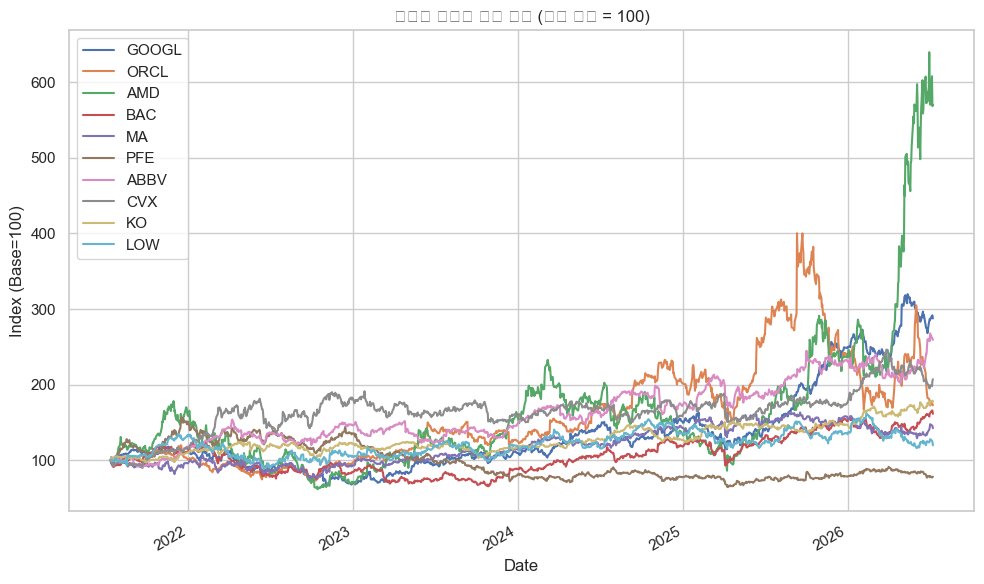

In [3]:
normalized = prices / prices.iloc[0] * 100

fig, ax = plt.subplots()
normalized.plot(ax=ax)
ax.set_title("종목별 정규화 가격 추이 (시작 시점 = 100)")
ax.set_ylabel("Index (Base=100)")
plt.tight_layout()
plt.show()


C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2024659970.py:4: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2024659970.py:4: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2024659970.py:4: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2024659970.py:4: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2024659970.py:4: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\2024659970.py:4: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout

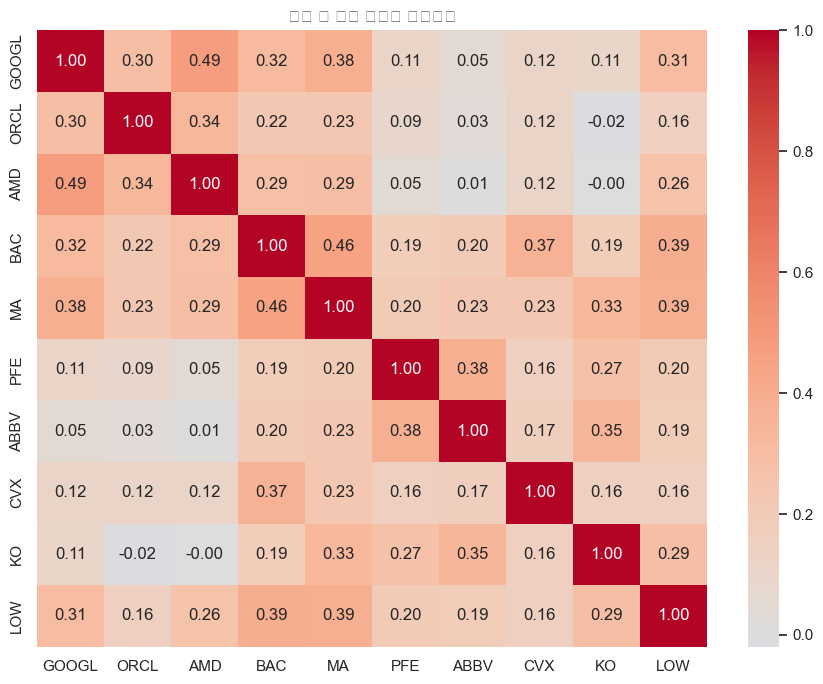

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(daily_returns.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("종목 간 일별 수익률 상관관계")
plt.tight_layout()
plt.show()


## 3. 포트폴리오 최적화 - 효율적 프론티어

연환산 기대수익률과 공분산 행렬을 바탕으로,
- 무작위 포트폴리오 5,000개를 시뮬레이션해 프론티어 형태를 시각적으로 확인하고
- `scipy.optimize`로 **샤프비율 최대화 포트폴리오**와 **최소분산 포트폴리오**를 정확히 계산한다.


In [5]:
mean_returns = annualize_returns(daily_returns)
cov_matrix = annualize_cov(daily_returns)

random_port = random_portfolios(mean_returns, cov_matrix, n_portfolios=5000, risk_free_rate=risk_free_rate)
frontier = efficient_frontier(mean_returns, cov_matrix, n_points=50)

max_sharpe_weights = max_sharpe_portfolio(mean_returns, cov_matrix, risk_free_rate)
min_vol_weights = min_volatility_portfolio(mean_returns, cov_matrix)

max_sharpe_ret, max_sharpe_vol, max_sharpe_sr = portfolio_performance(max_sharpe_weights, mean_returns, cov_matrix, risk_free_rate)
min_vol_ret, min_vol_vol, min_vol_sr = portfolio_performance(min_vol_weights, mean_returns, cov_matrix, risk_free_rate)

print(f"Max Sharpe  -> 기대수익률: {max_sharpe_ret:.2%}, 변동성: {max_sharpe_vol:.2%}, 샤프비율: {max_sharpe_sr:.2f}")
print(f"Min Vol     -> 기대수익률: {min_vol_ret:.2%}, 변동성: {min_vol_vol:.2%}, 샤프비율: {min_vol_sr:.2f}")


Max Sharpe  -> 기대수익률: 24.05%, 변동성: 16.29%, 샤프비율: 1.26
Min Vol     -> 기대수익률: 14.43%, 변동성: 12.92%, 샤프비율: 0.84


C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1280437560.py:13: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1280437560.py:13: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1280437560.py:13: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1280437560.py:13: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1280437560.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1280437560.py:13: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.ti

C:\Users\vkdlf\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vkdlf\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vkdlf\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vkdlf\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vkdlf\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\vkdlf\anaconda

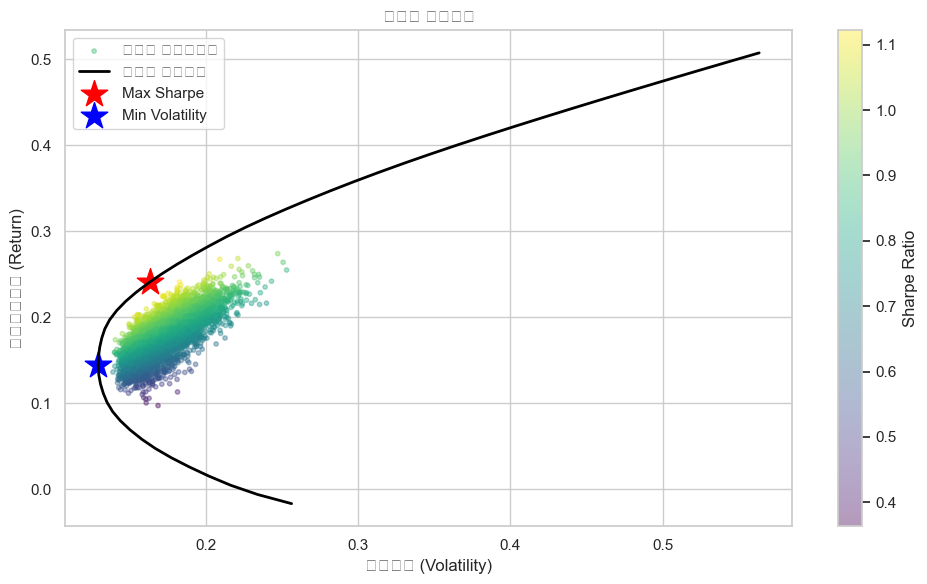

In [6]:
fig, ax = plt.subplots()
sc = ax.scatter(random_port["Volatility"], random_port["Return"], c=random_port["Sharpe"],
                 cmap="viridis", alpha=0.4, s=10, label="무작위 포트폴리오")
ax.plot(frontier["Volatility"], frontier["Return"], color="black", linewidth=2, label="효율적 프론티어")
ax.scatter([max_sharpe_vol], [max_sharpe_ret], color="red", marker="*", s=400, label="Max Sharpe")
ax.scatter([min_vol_vol], [min_vol_ret], color="blue", marker="*", s=400, label="Min Volatility")

plt.colorbar(sc, label="Sharpe Ratio")
ax.set_xlabel("연변동성 (Volatility)")
ax.set_ylabel("연기대수익률 (Return)")
ax.set_title("효율적 프론티어")
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
weights_df = pd.DataFrame({
    "Max Sharpe": max_sharpe_weights,
    "Min Volatility": min_vol_weights,
}, index=TICKERS)

weights_df.style.format("{:.1%}").bar(color="#5fba7d")


,Max Sharpe,Min Volatility
GOOGL,12.4%,7.1%
ORCL,0.6%,5.3%
AMD,14.8%,0.0%
BAC,0.0%,2.9%
MA,0.0%,2.1%
PFE,0.0%,7.9%
ABBV,34.1%,10.7%
CVX,15.9%,14.3%
KO,22.2%,45.4%
LOW,0.0%,4.2%


## 4. 최적 포트폴리오 성과 vs 벤치마크(S&P 500)
샤프비율 최대화 포트폴리오의 실제 일별 수익률을 재구성해 벤치마크와 누적수익률을 비교한다.

In [8]:
portfolio_daily_returns = daily_returns.dot(max_sharpe_weights)
portfolio_daily_returns.name = "Max Sharpe Portfolio"

comparison = pd.DataFrame({
    "Max Sharpe Portfolio": performance_summary(portfolio_daily_returns, risk_free_rate),
    "Benchmark (SPY)": performance_summary(benchmark_returns, risk_free_rate),
})
comparison


,Max Sharpe Portfolio,Benchmark (SPY)
CAGR,0.255014,0.128682
Volatility,0.162949,0.171771
Sharpe,1.345104,0.540555
MaxDrawdown,-0.204293,-0.244964


C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1562687827.py:10: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1562687827.py:10: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1562687827.py:10: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1562687827.py:10: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1562687827.py:10: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vkdlf\AppData\Local\Temp\ipykernel_15544\1562687827.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_la

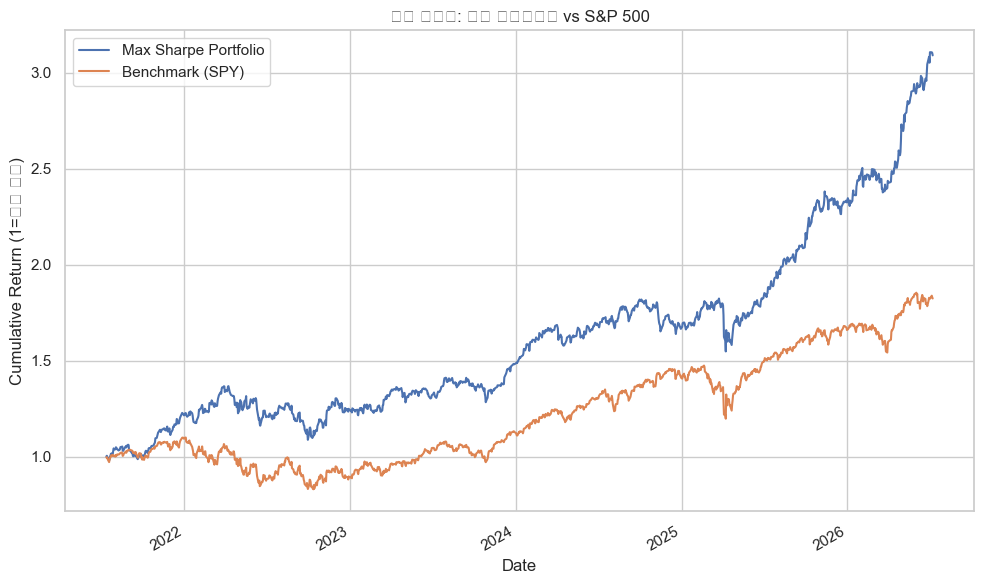

In [9]:
cum_portfolio = (1 + portfolio_daily_returns).cumprod()
cum_benchmark = (1 + benchmark_returns).cumprod()

fig, ax = plt.subplots()
cum_portfolio.plot(ax=ax, label="Max Sharpe Portfolio")
cum_benchmark.plot(ax=ax, label="Benchmark (SPY)")
ax.set_title("누적 수익률: 최적 포트폴리오 vs S&P 500")
ax.set_ylabel("Cumulative Return (1=시작 시점)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. 결론 및 한계

**주요 발견**
- 샤프비율 최대화 포트폴리오는 벤치마크(SPY) 대비 [실행 결과에 따라 채워넣기: 수익률/변동성/샤프비율 비교] 를 보였다.

**한계 및 향후 개선 방향**
- 최적화가 과거 데이터에 기반한 **in-sample** 결과이므로, 실제로는 walk-forward 방식의 리밸런싱 검증이 필요하다.
- 거래비용, 슬리피지, 세금이 반영되지 않았다.
- 공매도를 허용하지 않는 제약(0~100%)을 두었는데, 이는 실제 롱온리 펀드 운용과 유사한 가정이다.
- 무위험수익률은 미국 종목 기준 ^IRX(13주 국채) 자동조회값을 사용했으며, 그 외 시장은 수동 설정값을 사용한다.
